# Everything Script (organized + most recent vr.) 

In [123]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np 
from datetime import datetime
import time

import plotly.express as px
from plotly import graph_objs as go
from plotly.subplots import make_subplots
from plotly.offline import init_notebook_mode, iplot
import plotly.io as pio
pio.renderers.default = "iframe"

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [13]:
# load in all data

# asphalt 
asphalt_r_df = pd.read_csv("data/catherine/asphalt_primary.csv")
asphalt_l_df = pd.read_csv("data/catherine/asphalt_secondary.csv")
# brick
brick_r_df = pd.read_csv("data/catherine/brick_primary.csv")
brick_l_df = pd.read_csv("data/catherine/brick_secondary.csv")
# grass
grass_r_df = pd.read_csv("data/catherine/grass_primary.csv")
grass_l_df = pd.read_csv("data/catherine/grass_secondary.csv")

# multi data 
multi_r_df = pd.read_csv("data/catherine/multi_recordV2Primary.csv")
multi_l_df = pd.read_csv("data/catherine/multi_recordV2Secondary.csv") 

In [166]:
# add ground types
asphalt_r_df['ground_type'] = "asphalt"
asphalt_l_df['ground_type'] = "asphalt"
brick_r_df['ground_type'] = "brick"
brick_l_df['ground_type'] = "brick"
grass_r_df['ground_type'] = "grass"
grass_l_df['ground_type'] = "grass"

## functions 

In [43]:
def drop_columns(df, columns):
    df = df.drop(columns= columns)
    return df

In [17]:
def to_milliseconds(df): 
    df["date_time"] = pd.to_datetime(df['timestamp'], unit='ms')
    df["time_elapsed"] = (df['date_time'] - df['date_time'].iloc[0]).dt.total_seconds() * 100
    return df

In [ ]:
def make_lineplt():
    

In [ ]:
def make_heatmap():
    

## cleaning 

In [16]:
conditions = ["Grass", "Asphalt", "Brick", "Multi"]
data_by_condition = {
    "Grass":   (grass_r_df, grass_l_df),
    "Asphalt": (asphalt_r_df, asphalt_l_df),
    "Brick":   (brick_r_df, brick_l_df),
    "Multi": (multi_r_df, multi_l_df)
}

In [ ]:
# data dignostic 

In [ ]:
# drop unwanted data 

In [19]:
# convert to milliseconds  
for condition, (right_df, left_df) in data_by_condition.items():
    data_by_condition[condition] = (
        to_miliseconds(right_df),
        to_miliseconds(left_df)
    )

In [ ]:
# save csv as new csv 

In [ ]:
# reload in new cleaned data 

In [ ]:
# merge data frames

ashpalt_df = 
brick_df = 
grass_df = 
multi_df = 

## data analysis + visuals 

In [20]:
heel     = ['pressure_10', 'pressure_11', 'pressure_08']
midfoot  = ['pressure_03', 'pressure_07']
forefoot = ['pressure_02', 'pressure_05', 'pressure_04', 'pressure_06', 'pressure_09']
toes     = ['pressure_01', 'pressure_12']

sensor_cols = [*toes, *forefoot, *midfoot, *heel] 
sensor_cols2 = [*heel, *midfoot, *forefoot, *toes] 

In [29]:
y_min = np.inf
y_max = -np.inf

for cond in conditions:
    r_df, l_df = data_by_condition[cond]
    for col in sensor_cols:
        y_min = min(y_min, r_df[col].min(), l_df[col].min())
        y_max = max(y_max, r_df[col].max(), l_df[col].max())

pad = 0.05 * (y_max - y_min)
y_range = [y_min - pad, y_max + pad]

### line plot

### line plot

In [32]:
fig = make_subplots(rows=len(sensor_cols), cols=1, shared_xaxes=True, subplot_titles=sensor_cols)

trace_visibility_map = {c: [] for c in conditions}

# Build traces for each condition
for cond in conditions:
    r_df, l_df = data_by_condition[cond]
    for i, col in enumerate(sensor_cols, start=1):
        # right trace
        fig.add_trace(go.Scatter(
            x=r_df["time_elapsed"], y=r_df[col],
            mode="lines", name=f"{cond} | Right",
            line=dict(color="red"), opacity=0.8,
            legendgroup=f"{cond}_right",
            showlegend=(i == 1),
            visible=(cond == conditions[0])  # only first condition visible initially
        ), row=i, col=1)
        trace_visibility_map[cond].append(True)

        # left trace
        fig.add_trace(go.Scatter(
            x=l_df["time_elapsed"], y=l_df[col],
            mode="lines", name=f"{cond} | Left",
            line=dict(color="dodgerblue"), opacity=0.8,
            legendgroup=f"{cond}_left",
            showlegend=(i == 1),
            visible=(cond == conditions[0])
        ), row=i, col=1)
        trace_visibility_map[cond].append(True)

# buttons (one per condition)
n_traces_per_cond = 2 * len(sensor_cols)
total_traces = len(conditions) * n_traces_per_cond

buttons = []
for ci, cond in enumerate(conditions):
    vis = [False] * total_traces
    start = ci * n_traces_per_cond
    for k in range(n_traces_per_cond):
        vis[start + k] = True

    buttons.append(dict(
        label=cond,
        method="update",
        args=[
            {"visible": vis},
            {"title": f"Pressure Sensor Readings Over Time — {cond}"}
        ]
    ))

fig.update_layout(
    title=f"Pressure Sensor Readings Over Time — {conditions[0]}",
    height=100 * len(sensor_cols),
    width=1600,
    xaxis_title="Time Elapsed (ms)",
    updatemenus=[dict(
        type="buttons",
        direction="right",
        x=0.0, y=1.12,
        buttons=buttons
    )]
)

fig.update_yaxes(range=y_range)
fig.update_yaxes(title_text="Pressure")
fig.show()
fig.write_html("pressure_plot.html")

### heat map

In [41]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

conditions = ["Grass", "Asphalt", "Brick", "Multi"]
y = sensor_cols2

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Left Foot Pressure", "Right Foot Pressure"]
)

# Add 2 traces per condition (left + right)
for i, cond in enumerate(conditions):
    r_df, l_df = data_by_condition[cond]   # (right, left)

    Z_left = l_df[sensor_cols2].T.values
    Z_right = r_df[sensor_cols2].T.values
    x = r_df["time_elapsed"].values

    visible_now = (i == 0)  # show first condition initially

    fig.add_trace(
        go.Heatmap(
            z=Z_left,
            x=x,
            y=y,
            coloraxis="coloraxis",
            visible=visible_now,
            name=f"{cond} - Left",
        ),
        row=1, col=1
    )

    fig.add_trace(
        go.Heatmap(
            z=Z_right,
            x=x,
            y=y,
            coloraxis="coloraxis",
            visible=visible_now,
            name=f"{cond} - Right",
        ),
        row=2, col=1
    )

# Build TOP BUTTONS (not dropdown)
buttons = []
n_traces = len(conditions) * 2

for i, cond in enumerate(conditions):
    vis = [False] * n_traces
    vis[2*i] = True
    vis[2*i + 1] = True

    buttons.append(dict(
        label=cond,
        method="update",
        args=[
            {"visible": vis},
            {
                # IMPORTANT: update title.text ONLY
                "title.text": f"Pressure Sensor Heatmaps (Left vs Right) — {cond}"
            }
        ],
    ))

fig.update_layout(
    title=dict(
        text=f"Pressure Sensor Heatmaps (Left vs Right) — {conditions[0]}",
        x=0.5,
        xanchor="center",
        y=0.96,          # BELOW the buttons
        yanchor="top",
        font=dict(size=18)
    ),

    coloraxis=dict(colorscale="Viridis"),
    height=900,

    updatemenus=[
        dict(
            type="buttons",
            buttons=buttons,
            direction="right",
            x=0.0,
            xanchor="left",
            y=1.12,        # ABOVE the title
            yanchor="top",
            pad=dict(r=10, t=10),
            showactive=True
        )
    ],

    margin=dict(t=140, r=30, l=60, b=60)
)

fig.update_xaxes(side="top", row=1, col=1)
fig.show()
fig.write_html("heat_plot.html")

## ML - Ground Detection 

In [45]:
## check data for ML analysis 

In [ ]:
## set up dummy variables 

In [ ]:
## set up test & train 

In [ ]:
## set up logreg 

### trail run (pls organize after)

In [160]:
all_grass = [grass_r_df, grass_l_df]
all_grass_df = pd.concat(all_grass).sort_values(by='timestamp')

In [101]:
# merge data sets 
all_data = [grass_r_df, grass_l_df, brick_r_df, brick_l_df, asphalt_r_df, asphalt_l_df]
all_df = pd.concat(all_data).sort_values(by='timestamp')
# all_df

In [102]:
# drop unecissary columns 
columns = ['magn_x', 'magn_y', 'magn_z', 'corrupt']
all_df = drop_columns(all_df, columns)
all_df

,sole_id,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,pressure_01,pressure_02,...,pressure_06,pressure_07,pressure_08,pressure_09,pressure_10,pressure_11,pressure_12,date_time,time_elapsed,ground_type
0,2,1768508082432,914,507,9973,3665,-35430,-1221,199,151,...,277,482,428,250,379,451,166,2026-01-15 20:14:42.432,0.0,asphalt
1,2,1768508082448,904,502,9964,7330,-34208,0,197,151,...,289,495,427,255,384,444,164,2026-01-15 20:14:42.448,1.6,asphalt
0,1,1768508082448,-646,531,9968,0,-81855,15882,309,183,...,293,455,315,284,469,382,208,2026-01-15 20:14:42.448,0.0,asphalt
2,2,1768508082464,894,492,9964,8552,-34208,0,200,152,...,283,499,424,254,382,438,153,2026-01-15 20:14:42.464,3.2,asphalt
1,1,1768508082464,-650,540,9973,8552,-87964,14660,309,186,...,279,454,316,283,460,386,191,2026-01-15 20:14:42.464,1.6,asphalt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4029,2,1768508592688,473,483,10059,10995,-42760,-1221,155,174,...,294,349,324,292,303,378,164,2026-01-15 20:23:12.688,6446.4,brick
4030,2,1768508592704,473,483,10059,9773,-43982,-1221,162,177,...,296,376,339,292,305,385,160,2026-01-15 20:23:12.704,6448.0,brick
4031,2,1768508592720,492,478,10064,8552,-46425,0,165,182,...,290,406,358,285,299,389,153,2026-01-15 20:23:12.720,6449.6,brick
4032,2,1768508592736,488,478,10059,6108,-46425,0,178,185,...,268,408,361,274,295,387,137,2026-01-15 20:23:12.736,6451.2,brick


<Axes: >

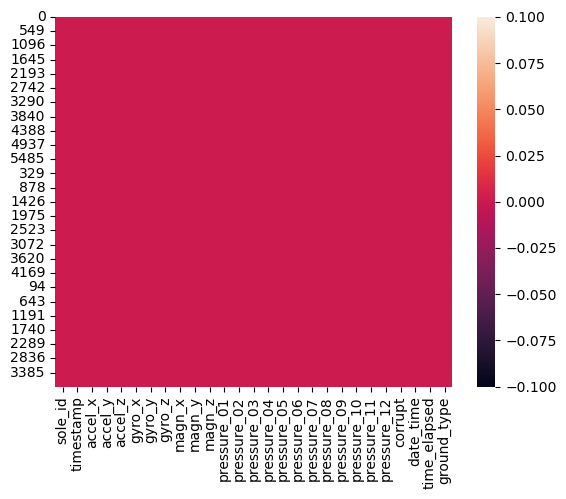

In [91]:
# check dataset 
sns.heatmap(all_df.isnull())

In [92]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28496 entries, 0 to 4033
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   sole_id       28496 non-null  int64         
 1   timestamp     28496 non-null  int64         
 2   accel_x       28496 non-null  int64         
 3   accel_y       28496 non-null  int64         
 4   accel_z       28496 non-null  int64         
 5   gyro_x        28496 non-null  int64         
 6   gyro_y        28496 non-null  int64         
 7   gyro_z        28496 non-null  int64         
 8   magn_x        28496 non-null  int64         
 9   magn_y        28496 non-null  int64         
 10  magn_z        28496 non-null  int64         
 11  pressure_01   28496 non-null  int64         
 12  pressure_02   28496 non-null  int64         
 13  pressure_03   28496 non-null  int64         
 14  pressure_04   28496 non-null  int64         
 15  pressure_05   28496 non-null  int64       

In [103]:
# make dummies of non-null objects 
ground_type = pd.get_dummies(all_df['ground_type'], drop_first=True)

all_df.drop(['ground_type'], axis = 1, inplace = True)
all_df = pd.concat([all_df, ground_type], axis = 1)

In [105]:
all_df

,sole_id,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,pressure_01,pressure_02,...,pressure_07,pressure_08,pressure_09,pressure_10,pressure_11,pressure_12,date_time,time_elapsed,brick,grass
0,2,1768508082432,914,507,9973,3665,-35430,-1221,199,151,...,482,428,250,379,451,166,2026-01-15 20:14:42.432,0.0,False,False
1,2,1768508082448,904,502,9964,7330,-34208,0,197,151,...,495,427,255,384,444,164,2026-01-15 20:14:42.448,1.6,False,False
0,1,1768508082448,-646,531,9968,0,-81855,15882,309,183,...,455,315,284,469,382,208,2026-01-15 20:14:42.448,0.0,False,False
2,2,1768508082464,894,492,9964,8552,-34208,0,200,152,...,499,424,254,382,438,153,2026-01-15 20:14:42.464,3.2,False,False
1,1,1768508082464,-650,540,9973,8552,-87964,14660,309,186,...,454,316,283,460,386,191,2026-01-15 20:14:42.464,1.6,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4029,2,1768508592688,473,483,10059,10995,-42760,-1221,155,174,...,349,324,292,303,378,164,2026-01-15 20:23:12.688,6446.4,True,False
4030,2,1768508592704,473,483,10059,9773,-43982,-1221,162,177,...,376,339,292,305,385,160,2026-01-15 20:23:12.704,6448.0,True,False
4031,2,1768508592720,492,478,10064,8552,-46425,0,165,182,...,406,358,285,299,389,153,2026-01-15 20:23:12.720,6449.6,True,False
4032,2,1768508592736,488,478,10059,6108,-46425,0,178,185,...,408,361,274,295,387,137,2026-01-15 20:23:12.736,6451.2,True,False


In [104]:
print(all_df.columns)

Index(['sole_id', 'timestamp', 'accel_x', 'accel_y', 'accel_z', 'gyro_x',
       'gyro_y', 'gyro_z', 'pressure_01', 'pressure_02', 'pressure_03',
       'pressure_04', 'pressure_05', 'pressure_06', 'pressure_07',
       'pressure_08', 'pressure_09', 'pressure_10', 'pressure_11',
       'pressure_12', 'date_time', 'time_elapsed', 'brick', 'grass'],
      dtype='object')


In [111]:
# predict grass vs. not_grass
target = "grass"
y = all_df[target].astype(int)

In [112]:
feature_cols = [
    c for c in all_df.columns
    if c.startswith("pressure_") or c.startswith("accel_") or c.startswith("gyro_")
]

X = all_df[feature_cols].apply(pd.to_numeric, errors="coerce")

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

In [125]:
# LOGREG ANALYSIS

logmodel = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=5000))
])

logmodel.fit(X_train, y_train)
predictions_log = logmodel.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions_log))
print(confusion_matrix(y_test, predictions_log))
print(classification_report(y_test, predictions_log))

Accuracy: 0.5854485904784186
[[3444 2331]
 [1213 1561]]
              precision    recall  f1-score   support

           0       0.74      0.60      0.66      5775
           1       0.40      0.56      0.47      2774

    accuracy                           0.59      8549
   macro avg       0.57      0.58      0.56      8549
weighted avg       0.63      0.59      0.60      8549



In [126]:
import pandas as pd

coefs = logmodel.named_steps["clf"].coef_[0]
coef_df = pd.DataFrame({"feature": feature_cols, "coef": coefs}).sort_values("coef", ascending=False)

coef_df.head(10)      # most “pro-target” features

,feature,coef
7,pressure_02,0.998098
12,pressure_07,0.623191
10,pressure_05,0.287585
13,pressure_08,0.260504
11,pressure_06,0.148684
6,pressure_01,0.107107
14,pressure_09,0.061473
4,gyro_y,0.048165
2,accel_z,0.045149
0,accel_x,0.026590


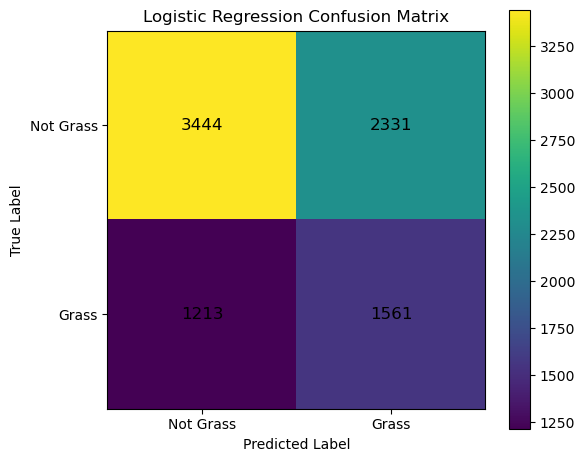

In [130]:
# create matrix 
cm = confusion_matrix(y_test, predictions_log)

# plot matrix 
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center", fontsize=12)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Not Grass", "Grass"])
ax.set_yticklabels(["Not Grass", "Grass"])

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Logistic Regression Confusion Matrix")

plt.colorbar(im)
plt.tight_layout()
plt.show()

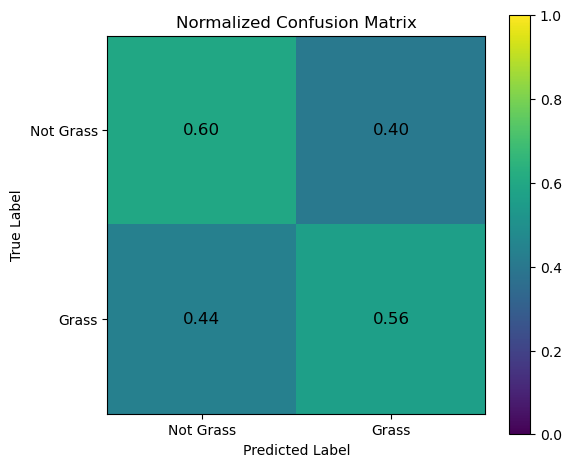

In [131]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_norm, vmin=0, vmax=1)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}",
                ha="center", va="center", fontsize=12)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Not Grass", "Grass"])
ax.set_yticklabels(["Not Grass", "Grass"])

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Normalized Confusion Matrix")

plt.colorbar(im)
plt.tight_layout()
plt.show()


In [133]:
# LDA Analysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearDiscriminantAnalysis())
])


In [135]:
target = "grass"   # or "brick"

y = all_df[target].astype(int)

feature_cols = [
    c for c in all_df.columns
    if c.startswith("pressure_") or c.startswith("accel_") or c.startswith("gyro_")
]

X = all_df[feature_cols]


In [136]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=0,
    stratify=y
)


In [137]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis())
])

lda_model.fit(X_train, y_train)
lda_preds = lda_model.predict(X_test)


In [138]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("LDA Accuracy:", accuracy_score(y_test, lda_preds))
print(confusion_matrix(y_test, lda_preds))
print(classification_report(y_test, lda_preds))


LDA Accuracy: 0.6860451514797052
[[5588  187]
 [2497  277]]
              precision    recall  f1-score   support

           0       0.69      0.97      0.81      5775
           1       0.60      0.10      0.17      2774

    accuracy                           0.69      8549
   macro avg       0.64      0.53      0.49      8549
weighted avg       0.66      0.69      0.60      8549



In [140]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=0,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)


In [141]:
print("RF Accuracy:", accuracy_score(y_test, rf_preds))
print(confusion_matrix(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

RF Accuracy: 0.9184699964908176
[[5638  137]
 [ 560 2214]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      5775
           1       0.94      0.80      0.86      2774

    accuracy                           0.92      8549
   macro avg       0.93      0.89      0.90      8549
weighted avg       0.92      0.92      0.92      8549



In [142]:
print("LogReg:", accuracy_score(y_test, predictions_log))
print("LDA:", accuracy_score(y_test, lda_preds))
print("RF:", accuracy_score(y_test, rf_preds))

LogReg: 0.5854485904784186
LDA: 0.6860451514797052
RF: 0.9184699964908176


In [143]:
import pandas as pd

rf_importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
)

pressure_importance = rf_importances[
    rf_importances.index.str.startswith("pressure_")
].sort_index()


In [144]:
import numpy as np

sensor_layout = {
    "pressure_01": (0.5, 0.9),  # toes
    "pressure_02": (0.3, 0.8),
    "pressure_03": (0.7, 0.8),
    "pressure_04": (0.2, 0.6),
    "pressure_05": (0.5, 0.6),
    "pressure_06": (0.8, 0.6),
    "pressure_07": (0.3, 0.4),
    "pressure_08": (0.7, 0.4),
    "pressure_09": (0.5, 0.3),
    "pressure_10": (0.3, 0.1),
    "pressure_11": (0.5, 0.1),
    "pressure_12": (0.7, 0.1)
}


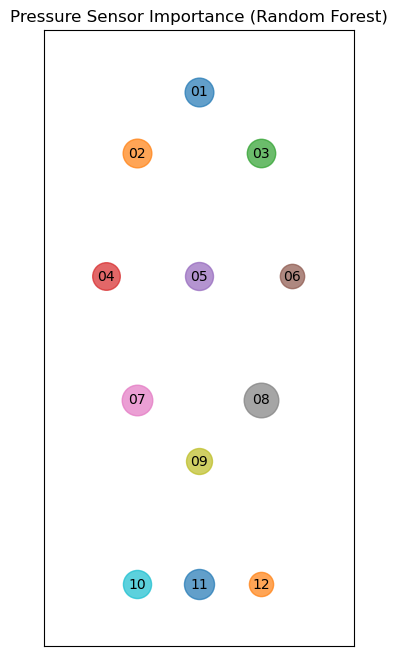

In [145]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4,8))

for sensor, (x,ypos) in sensor_layout.items():
    importance = pressure_importance.get(sensor, 0)
    
    ax.scatter(x, ypos,
               s=importance*8000,   # scale bubble size
               alpha=0.7)
    
    ax.text(x, ypos, sensor.split("_")[1],
            ha="center", va="center")

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Pressure Sensor Importance (Random Forest)")

plt.show()


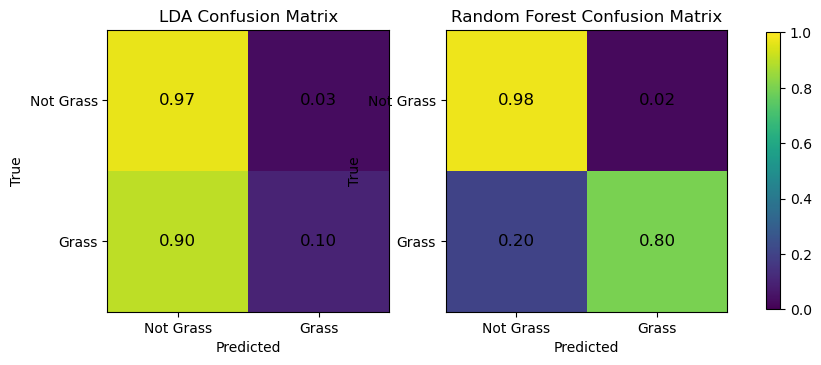

In [195]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_cm(ax, y_true, y_pred, title, labels=("Not Grass", "Grass"), normalize=False):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm, vmin=0, vmax=1 if normalize else None)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(labels); ax.set_yticklabels(labels)

    # numbers on cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            txt = f"{cm[i,j]:.2f}" if normalize else f"{int(cm[i,j])}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=12)

    return im

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im1 = plot_cm(axes[0], y_test, lda_preds, "LDA Confusion Matrix", normalize=True)
im2 = plot_cm(axes[1], y_test, rf_preds,  "Random Forest Confusion Matrix", normalize=True)

fig.colorbar(im2, ax=axes.ravel().tolist(), shrink=0.9)
plt.show()


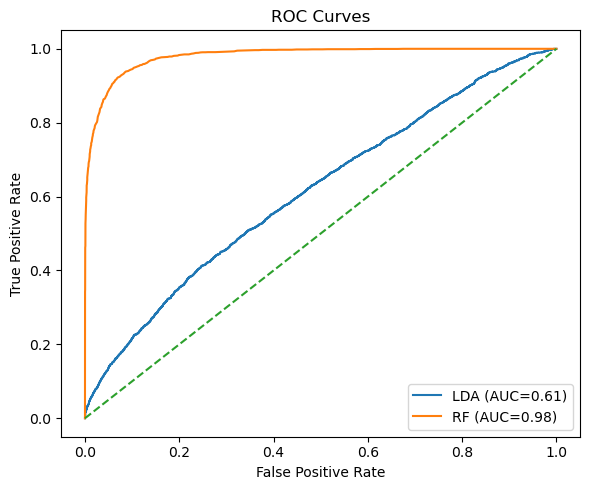

In [147]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# probabilities for class 1
lda_prob = lda_model.predict_proba(X_test)[:, 1]
rf_prob  = rf_model.predict_proba(X_test)[:, 1]

fpr_lda, tpr_lda, _ = roc_curve(y_test, lda_prob)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, rf_prob)

auc_lda = auc(fpr_lda, tpr_lda)
auc_rf  = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_lda, tpr_lda, label=f"LDA (AUC={auc_lda:.2f})")
plt.plot(fpr_rf,  tpr_rf,  label=f"RF (AUC={auc_rf:.2f})")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()


## learning algorithm

In [148]:
import numpy as np

def window_features(df, feature_cols, window_size=50, step_size=25):
    Xw = []
    for start in range(0, len(df) - window_size + 1, step_size):
        chunk = df.iloc[start:start+window_size][feature_cols]

        feats = {}
        for c in feature_cols:
            vals = chunk[c].values
            feats[f"{c}_mean"] = np.mean(vals)
            feats[f"{c}_std"]  = np.std(vals)
            feats[f"{c}_max"]  = np.max(vals)
        Xw.append(feats)

    return pd.DataFrame(Xw)


In [149]:
def predict_percent_windowed(csv_path, model, feature_cols, window_size=50, step_size=25):
    df = pd.read_csv(csv_path)
    Xw = window_features(df, feature_cols, window_size, step_size)
    preds = model.predict(Xw)
    percent = pd.Series(preds).value_counts(normalize=True) * 100
    return percent, preds
c

In [158]:
model = rf_model
rf_model

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=0)

In [157]:
import joblib

joblib.dump(
    {"model": model, "feature_cols": feature_cols, "time_col": "time_elapsed"},
    "ground_model.joblib"
)

['ground_model.joblib']

In [163]:
import pandas as pd
import numpy as np
import joblib

def predict_percent_time(data, bundle_path="ground_model.joblib", time_unit="ms"):
    """
    data: either a CSV filepath (str) OR a pandas DataFrame
    """
    bundle = joblib.load(bundle_path)
    model = bundle["model"]
    feature_cols = bundle["feature_cols"]
    time_col = bundle.get("time_col", "time_elapsed")

    # ✅ Accept both path or df
    if isinstance(data, str):
        df = pd.read_csv(data)
    elif isinstance(data, pd.DataFrame):
        df = data.copy()
    else:
        raise TypeError("data must be a filepath (str) or a pandas DataFrame")

    # --- features ---
    X = df[feature_cols].apply(pd.to_numeric, errors="coerce")

    # drop rows with missing features or time
    if time_col not in df.columns:
        raise ValueError(f"Time column '{time_col}' not found in data.")

    t = df[time_col]

    # keep only complete rows
    keep = X.notna().all(axis=1) & pd.to_numeric(t, errors="coerce").notna()
    df = df.loc[keep].copy()
    X = X.loc[keep]

    # --- compute dt ---
    t = df[time_col]

    # datetime-like
    if np.issubdtype(t.dtype, np.datetime64) or str(t.dtype).startswith("datetime"):
        t = pd.to_datetime(t, errors="coerce")
        df = df.loc[t.notna()].copy()
        X = X.loc[df.index]
        t = t.loc[df.index]
        dt = t.diff().dt.total_seconds()
    else:
        t = pd.to_numeric(t, errors="coerce")
        dt = t.diff()

        if time_unit == "ms":
            dt = dt / 1000.0
        elif time_unit == "s":
            dt = dt.astype(float)
        else:
            raise ValueError("time_unit must be 'ms' or 's'.")

    dt = dt.fillna(0)
    dt[dt < 0] = 0

    # --- predict ---
    preds = model.predict(X)

    # --- time-weighted percent ---
    time_by_class = pd.Series(dt.values).groupby(preds).sum()
    total_time = time_by_class.sum()

    percent = (time_by_class / total_time * 100).sort_values(ascending=False)
    return percent, preds, dt, df

In [191]:
input_frame = all_df

In [192]:
percent, preds, dt, df_used = predict_percent_time(
    input_frame,
    bundle_path="ground_model.joblib",
    time_unit="ms"   # change to "s" if your time_elapsed is already seconds
)

# print(percent)
positive = "grass"          
negative = f"not_{positive}"

print(f"Label meaning: 1 = {positive}, 0 = {negative}")
print("y counts:\n", y.value_counts().rename({0: negative, 1: positive}))

Label meaning: 1 = grass, 0 = not_grass
y counts:
 grass
not_grass    19250
grass         9246
Name: count, dtype: int64


In [193]:
import pandas as pd

positive = "grass"
negative = "not_grass"

# True labels must match df_used rows
true_labels = df_used[positive].astype(int)   # because df_used still has dummy col "grass"
pred_labels = pd.Series(preds, index=df_used.index)

true_named = true_labels.map({0: negative, 1: positive})
pred_named = pred_labels.map({0: negative, 1: positive})

comparison = pd.DataFrame({"True": true_named, "Predicted": pred_named})
print(comparison.head(10))

print("\nConfusion table:")
print(pd.crosstab(comparison["True"], comparison["Predicted"]))

print("\nAccuracy (%):", (comparison["True"] == comparison["Predicted"]).mean() * 100)

        True  Predicted
0  not_grass  not_grass
1  not_grass  not_grass
0  not_grass  not_grass
2  not_grass  not_grass
1  not_grass  not_grass
2  not_grass  not_grass
3  not_grass  not_grass
3  not_grass  not_grass
4  not_grass  not_grass
5  not_grass  not_grass

Confusion table:
Predicted  grass  not_grass
True                       
grass       8686        560
not_grass    137      19113

Accuracy (%): 97.55404267265581


In [187]:
print("True distribution:")
print(true_named.value_counts())

print("\nPredicted distribution:")
print(pred_named.value_counts())

print("\nAgreement rate:")
print((true_named == pred_named).value_counts())

True distribution:
grass
not_grass    19250
grass         9246
Name: count, dtype: int64

Predicted distribution:
not_grass    19673
grass         8823
Name: count, dtype: int64

Agreement rate:
True     27799
False      697
Name: count, dtype: int64


In [183]:
print("Confusion Table:")
print(pd.crosstab(comparison["True"], comparison["Predicted"]))

Confusion Table:
Predicted  grass  not_grass
True                       
grass       8686        560
not_grass    137      19113


In [194]:
## looking into the model 

In [172]:
print("dt_seconds summary:")
print(dt.describe())

print("Total time (sec):", float(dt.sum()))
print("Fraction dt==0:", float((dt == 0).mean()))

dt_seconds summary:
count    28496.000000
mean         0.001082
std          0.001046
min          0.000000
25%          0.000000
50%          0.001600
75%          0.001600
max          0.003200
Name: time_elapsed, dtype: float64
Total time (sec): 30.828799999999987
Fraction dt==0: 0.42813026389668724


In [173]:
print("Percent by class:")
print(percent)

print("Sum of percent:", float(percent.sum()))

Percent by class:
0    77.101931
1    22.898069
dtype: float64
Sum of percent: 100.0


In [175]:
if "ground_type" in all_grass_df.columns:
    print(all_grass_df["ground_type"].value_counts())

ground_type
grass    9246
Name: count, dtype: int64


In [177]:
# print("Model classes:", bundle["model"].classes_ if hasattr(bundle["model"], "classes_") else "no classes_")

print("Percent:")
print(percent)
print("Percent sum:", float(percent.sum()))

print("dt summary:")
print(dt.describe())
print("Total time (sec):", float(dt.sum()))

Percent:
0    77.101931
1    22.898069
dtype: float64
Percent sum: 100.0
dt summary:
count    28496.000000
mean         0.001082
std          0.001046
min          0.000000
25%          0.000000
50%          0.001600
75%          0.001600
max          0.003200
Name: time_elapsed, dtype: float64
Total time (sec): 30.828799999999987


In [1]:
out = df_used.copy()
out["pred_ground"] = preds
out["dt_seconds"] = dt.values
out.to_csv("predicted_ground_timeline.csv", index=False)
print("Saved predicted_ground_timeline.csv")

NameError: name 'df_used' is not defined